In [1]:
import pandas as pd
import missingno
import sys

sys.path.insert(0, "../Modules")

from preprocessing_utils import *

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'

In [3]:
dataset = pd.read_csv(f'data/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv', encoding=enc)
geomorphological = pd.read_csv(f'data/{NUTS0}_{NUTS2}_Geomorphological_filled.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [4]:
dataset.head()

,x,y,dt_placement,nuts2,lau1,lau1_id,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,22.48398,40.64468,2010-01-01,κεντρικης μακεδονιας,αλεξανδρειας,8,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,478.8,38293.0,86.8,46.44911,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.390000,11.935000,6.845,7.618333,3.670476,9.961333,1.982765,18.738689,4.318686,29.464560,9.289931,0.015560,0.015560,0.015560,9,0,0
1,21.94079,40.97703,2010-01-01,κεντρικης μακεδονιας,αλμωπιας,9,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,985.8,24924.0,28.0,46.48134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.657273,11.324545,5.990,4.240266,1.734176,4.199935,1.072630,11.344401,2.127124,18.823986,6.621377,0.248551,0.248551,0.248551,12,0,0
2,22.89198,40.65603,2010-01-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,17,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,9.8,49674.0,5319.1,46.65786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.180000,13.470000,8.890,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,0.000000,0.000000,0.000000,12,0,0
3,23.98253,40.91510,2010-01-01,κεντρικης μακεδονιας,αμφιπολης,33,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,411.8,7169.0,22.3,47.42581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.742500,13.120000,8.365,8.059333,3.832476,9.231646,1.955639,14.550773,3.470297,20.603567,8.292500,0.055994,0.055994,0.055994,13,0,0
4,23.69108,40.49593,2010-01-01,κεντρικης μακεδονιας,αριστοτελη,27,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,747.0,16994.0,24.5,46.91682,0.036921,0.159004,0.193601,-0.159004,0.036921,0.159004,0.193601,-0.159004,0.0,0.0,0.0,0.0,11.447500,15.240000,7.655,9.412740,4.925685,8.219720,2.711017,15.334974,3.402690,18.882057,7.497680,1.750566,1.750566,1.750566,17,0,0


In [5]:
geomorphological.head()

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,24.05105,40.31951,2802.421393,4354.991527,14,231.417467,276.517281,188.889456,0.0,3.998248
1,24.05105,40.35544,1849.716366,697.392287,26,127.358018,145.408143,163.763939,0.0,2.006094
2,24.09803,40.31951,3388.512883,5473.471255,13,192.256866,239.376381,181.658242,0.0,3.609011
3,24.30947,40.15781,2116.919637,4867.646762,44,285.956649,945.458571,240.592577,0.0,3.887520
4,21.83449,40.75699,1316.915891,1522.054417,23,70.032765,642.795475,170.654884,0.0,1.059672


In [6]:
distances, indicies = calculate_nearest_topological(dataset, geomorphological)

In [7]:
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 9.045170238510034


In [8]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

In [9]:
for index in indicies:
    df_geo = df_geo.append(geomorphological.iloc[[index]])

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

In [10]:
dataset = pd.concat([dataset, df_geo], axis=1, join = 'outer')

In [11]:
dataset.head()

,x,y,dt_placement,nuts2,lau1,lau1_id,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,22.48398,40.64468,2010-01-01,κεντρικης μακεδονιας,αλεξανδρειας,8,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,478.8,38293.0,86.8,46.44911,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.390000,11.935000,6.845,7.618333,3.670476,9.961333,1.982765,18.738689,4.318686,29.464560,9.289931,0.015560,0.015560,0.015560,9,0,0,21798.191901,561.876983,3,148.634810,2.247180,180.067365,0.0,5.738407
1,21.94079,40.97703,2010-01-01,κεντρικης μακεδονιας,αλμωπιας,9,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,985.8,24924.0,28.0,46.48134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.657273,11.324545,5.990,4.240266,1.734176,4.199935,1.072630,11.344401,2.127124,18.823986,6.621377,0.248551,0.248551,0.248551,12,0,0,21799.947368,819.637594,34,54.056037,965.390539,175.271364,0.0,1.000000
2,22.89198,40.65603,2010-01-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,17,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,9.8,49674.0,5319.1,46.65786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.180000,13.470000,8.890,12.730000,5.510000,9.853333,3.612000,18.272222,6.046667,26.770000,11.750000,0.000000,0.000000,0.000000,12,0,0,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.0,24.343007
3,23.98253,40.91510,2010-01-01,κεντρικης μακεδονιας,αμφιπολης,33,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,411.8,7169.0,22.3,47.42581,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.742500,13.120000,8.365,8.059333,3.832476,9.231646,1.955639,14.550773,3.470297,20.603567,8.292500,0.055994,0.055994,0.055994,13,0,0,16270.860936,21.768793,12,152.028440,529.676707,197.614059,0.0,116.778232
4,23.69108,40.49593,2010-01-01,κεντρικης μακεδονιας,αριστοτελη,27,1,1,53,2010,0.201299,0.97953,0.5,0.866025,-2.449294e-16,1.0,747.0,16994.0,24.5,46.91682,0.036921,0.159004,0.193601,-0.159004,0.036921,0.159004,0.193601,-0.159004,0.0,0.0,0.0,0.0,11.447500,15.240000,7.655,9.412740,4.925685,8.219720,2.711017,15.334974,3.402690,18.882057,7.497680,1.750566,1.750566,1.750566,17,0,0,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.0,1.033661


<AxesSubplot:>

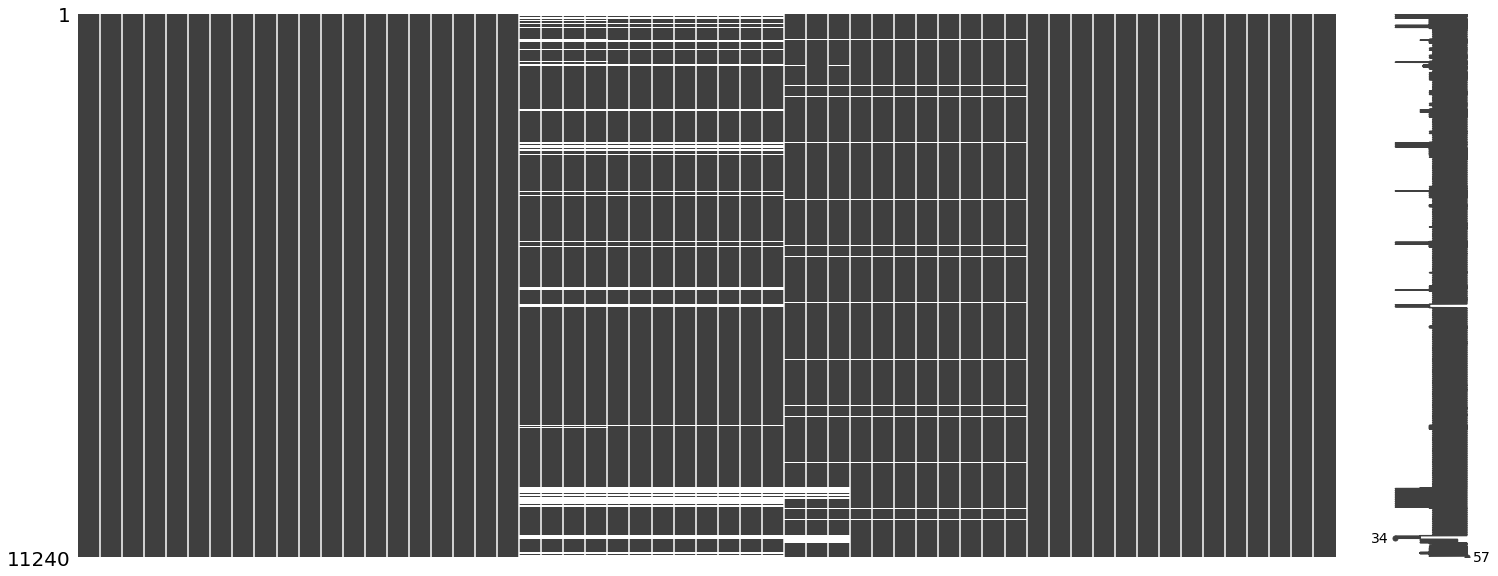

In [12]:
missingno.matrix(dataset)

In [13]:
cols = dataset.columns

In [14]:
cols

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'lau1_id', 'day', 'month',
       'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'week_sin', 'week_cos', 'area', 'population', 'population_density',
       'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'mosq_pred', 'mosq_previous', 'case',
       'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m'],
      dtype='object')

In [15]:
len(cols)

57

In [16]:
rearranged = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'lau1_id', 'day', 'month',
       'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'week_sin', 'week_cos', 'area', 'population', 'population_density',
       'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'mosq_pred', 'mosq_previous', 'case']

In [17]:
len(rearranged)

57

In [18]:
dataset = dataset[rearranged]

In [19]:
dataset.to_csv(f"data/{NUTS0}_{NUTS2}_WNV_Dataset_2010_2021.csv", encoding = enc, index = False)